In [1]:
!pip install pyodbc pandas sqlalchemy pyarrow

In [2]:
import pandas as pd
import pyodbc
from sqlalchemy import create_engine, text
import urllib
import sys
import os

In [3]:
#SERVER   = "MENFROYT\\SQLEXPRESS"                                                             # if you are using SQL Server Express
#DATABASE = "HealthcareDB"
#CSV_PATH = "healthcare_dataset_limpio.csv" 

Credenciales temporales utilizadas solo para este proceso

In [4]:
SERVER   = "SQL8011.site4now.net"                                                             # if you are using SQL Server Express
DATABASE = "db_ac6bde_healthcaredb"
CSV_PATH = "healthcare_dataset_limpio.csv" 

In [5]:
SQL_USER = os.environ.get('SQL_USER', 'db_ac6bde_healthcaredb_admin')
SQL_PASSWORD = os.environ.get('SQL_PASSWORD', 'Menfroyt99')

CONN_MASTER = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE=master;"
    f"UID={SQL_USER};"
    f"PWD={SQL_PASSWORD};"
)
CONN_DB = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"UID={SQL_USER};"
    f"PWD={SQL_PASSWORD};"
)
params     = urllib.parse.quote_plus(CONN_DB)
ENGINE_URL = f"mssql+pyodbc:///?odbc_connect={params}"

In [6]:
def create_database():
    print("=" * 60)
    print("STEP 1 — Create database")
    print("=" * 60)
    try:
        conn = pyodbc.connect(CONN_MASTER, autocommit=True)
        cursor = conn.cursor()
        cursor.execute(f"""
            IF NOT EXISTS (
                SELECT name FROM sys.databases WHERE name = N'{DATABASE}'
            )
            BEGIN
                CREATE DATABASE [{DATABASE}]
                PRINT 'Database created.'
            END
            ELSE
                PRINT 'Database already exists.'
        """)
        conn.close()
        print(f"  Database '{DATABASE}' is ready.\n")
    except Exception as e:
        print(f"  ERROR creating database: {e}")
        sys.exit(1)

In [7]:
DDL = [
    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_medical_condition' AND xtype='U')
    CREATE TABLE dim_medical_condition (
        condition_id    INT           IDENTITY(1,1) NOT NULL,
        condition_name  NVARCHAR(100) NOT NULL,
        CONSTRAINT PK_dim_medical_condition        PRIMARY KEY (condition_id),
        CONSTRAINT UQ_dim_medical_condition_name   UNIQUE      (condition_name)
    )
    """,
 
    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_medication' AND xtype='U')
    CREATE TABLE dim_medication (
        medication_id    INT           IDENTITY(1,1) NOT NULL,
        medication_name  NVARCHAR(100) NOT NULL,
        CONSTRAINT PK_dim_medication        PRIMARY KEY (medication_id),
        CONSTRAINT UQ_dim_medication_name   UNIQUE      (medication_name)
    )
    """,
 

    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_insurer' AND xtype='U')
    CREATE TABLE dim_insurer (
        insurer_id    INT           IDENTITY(1,1) NOT NULL,
        insurer_name  NVARCHAR(100) NOT NULL,
        CONSTRAINT PK_dim_insurer        PRIMARY KEY (insurer_id),
        CONSTRAINT UQ_dim_insurer_name   UNIQUE      (insurer_name)
    )
    """,
 

    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_admission_type' AND xtype='U')
    CREATE TABLE dim_admission_type (
        admission_type_id    INT          IDENTITY(1,1) NOT NULL,
        admission_type_name  NVARCHAR(50) NOT NULL,
        CONSTRAINT PK_dim_admission_type        PRIMARY KEY (admission_type_id),
        CONSTRAINT UQ_dim_admission_type_name   UNIQUE      (admission_type_name)
    )
    """,
 

    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_test_result' AND xtype='U')
    CREATE TABLE dim_test_result (
        result_id    INT          IDENTITY(1,1) NOT NULL,
        result_name  NVARCHAR(50) NOT NULL,
        CONSTRAINT PK_dim_test_result        PRIMARY KEY (result_id),
        CONSTRAINT UQ_dim_test_result_name   UNIQUE      (result_name)
    )
    """,
 

    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_doctor' AND xtype='U')
    CREATE TABLE dim_doctor (
        doctor_id    INT           IDENTITY(1,1) NOT NULL,
        doctor_name  NVARCHAR(150) NOT NULL,
        CONSTRAINT PK_dim_doctor        PRIMARY KEY (doctor_id),
        CONSTRAINT UQ_dim_doctor_name   UNIQUE      (doctor_name)
    )
    """,
 

    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_hospital' AND xtype='U')
    CREATE TABLE dim_hospital (
        hospital_id    INT           IDENTITY(1,1) NOT NULL,
        hospital_name  NVARCHAR(200) NOT NULL,
        CONSTRAINT PK_dim_hospital        PRIMARY KEY (hospital_id),
        CONSTRAINT UQ_dim_hospital_name   UNIQUE      (hospital_name)
    )
    """,
 

    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='dim_date' AND xtype='U')
    CREATE TABLE dim_date (
        date_id          INT          NOT NULL,
        full_date        DATE         NOT NULL,
        year             SMALLINT     NOT NULL,
        quarter          TINYINT      NOT NULL,
        month            TINYINT      NOT NULL,
        month_name       NVARCHAR(20) NOT NULL,
        week_of_year     TINYINT      NOT NULL,
        day_of_month     TINYINT      NOT NULL,
        day_of_week      TINYINT      NOT NULL,   -- 1=Monday ... 7=Sunday
        day_name         NVARCHAR(20) NOT NULL,
        is_weekend       BIT          NOT NULL,
        CONSTRAINT PK_dim_date   PRIMARY KEY (date_id),
        CONSTRAINT UQ_dim_date   UNIQUE      (full_date)
    )
    """,
 

    """
    IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='fact_hospitalization' AND xtype='U')
    CREATE TABLE fact_hospitalization (
        hospitalization_id    INT           IDENTITY(1,1) NOT NULL,
        -- Degenerate patient attributes
        patient_name          NVARCHAR(150) NOT NULL,
        age                   SMALLINT      NOT NULL,
        gender                NVARCHAR(10)  NOT NULL,
        blood_type            NVARCHAR(5)   NOT NULL,
        room_number           SMALLINT      NOT NULL,
        -- Foreign keys to dimension tables
        condition_id          INT           NOT NULL,
        medication_id         INT           NOT NULL,
        insurer_id            INT           NOT NULL,
        admission_type_id     INT           NOT NULL,
        result_id             INT           NOT NULL,
        doctor_id             INT           NOT NULL,
        hospital_id           INT           NOT NULL,
        admission_date_id     INT           NOT NULL,
        discharge_date_id     INT           NOT NULL,
        -- Metrics
        billing_amount        DECIMAL(12,2) NOT NULL,
        length_of_stay        SMALLINT      NOT NULL,
        -- Primary key
        CONSTRAINT PK_fact_hospitalization PRIMARY KEY (hospitalization_id),
        -- Referential integrity
        CONSTRAINT FK_fact_condition      FOREIGN KEY (condition_id)      REFERENCES dim_medical_condition(condition_id),
        CONSTRAINT FK_fact_medication     FOREIGN KEY (medication_id)     REFERENCES dim_medication(medication_id),
        CONSTRAINT FK_fact_insurer        FOREIGN KEY (insurer_id)        REFERENCES dim_insurer(insurer_id),
        CONSTRAINT FK_fact_admission_type FOREIGN KEY (admission_type_id) REFERENCES dim_admission_type(admission_type_id),
        CONSTRAINT FK_fact_result         FOREIGN KEY (result_id)         REFERENCES dim_test_result(result_id),
        CONSTRAINT FK_fact_doctor         FOREIGN KEY (doctor_id)         REFERENCES dim_doctor(doctor_id),
        CONSTRAINT FK_fact_hospital       FOREIGN KEY (hospital_id)       REFERENCES dim_hospital(hospital_id),
        CONSTRAINT FK_fact_admission_date FOREIGN KEY (admission_date_id) REFERENCES dim_date(date_id),
        CONSTRAINT FK_fact_discharge_date FOREIGN KEY (discharge_date_id) REFERENCES dim_date(date_id)
    )
    """,

    """
    IF NOT EXISTS (SELECT * FROM sys.indexes
                   WHERE name = 'IX_fact_condition'
                   AND object_id = OBJECT_ID('fact_hospitalization'))
        CREATE INDEX IX_fact_condition      ON fact_hospitalization (condition_id)
    """,
    """
    IF NOT EXISTS (SELECT * FROM sys.indexes
                   WHERE name = 'IX_fact_insurer'
                   AND object_id = OBJECT_ID('fact_hospitalization'))
        CREATE INDEX IX_fact_insurer        ON fact_hospitalization (insurer_id)
    """,
    """
    IF NOT EXISTS (SELECT * FROM sys.indexes
                   WHERE name = 'IX_fact_admission_date'
                   AND object_id = OBJECT_ID('fact_hospitalization'))
        CREATE INDEX IX_fact_admission_date ON fact_hospitalization (admission_date_id)
    """,
    """
    IF NOT EXISTS (SELECT * FROM sys.indexes
                   WHERE name = 'IX_fact_hospital'
                   AND object_id = OBJECT_ID('fact_hospitalization'))
        CREATE INDEX IX_fact_hospital       ON fact_hospitalization (hospital_id)
    """,
    """
    IF NOT EXISTS (SELECT * FROM sys.indexes
                   WHERE name = 'IX_fact_admission_type'
                   AND object_id = OBJECT_ID('fact_hospitalization'))
        CREATE INDEX IX_fact_admission_type ON fact_hospitalization (admission_type_id)
    """,
]

In [8]:
def create_tables(engine):
    print("=" * 60)
    print("STEP 2 — Create tables and indexes")
    print("=" * 60)
    with engine.connect() as conn:
        for ddl in DDL:
            conn.execute(text(ddl))
        conn.commit()
    print("  All tables and indexes created successfully.\n")

In [9]:
def generate_dim_date(start_date="2019-01-01", end_date="2024-12-31"):
    month_names = {
        1:"January",  2:"February", 3:"March",    4:"April",
        5:"May",      6:"June",     7:"July",      8:"August",
        9:"September",10:"October", 11:"November", 12:"December"
    }
    day_names = {
        0:"Monday", 1:"Tuesday", 2:"Wednesday", 3:"Thursday",
        4:"Friday", 5:"Saturday", 6:"Sunday"
    }
    dates = pd.date_range(start=start_date, end=end_date, freq="D")
    rows  = []
    for d in dates:
        rows.append({
            "date_id":      int(d.strftime("%Y%m%d")),
            "full_date":    d.date(),
            "year":         d.year,
            "quarter":      d.quarter,
            "month":        d.month,
            "month_name":   month_names[d.month],
            "week_of_year": int(d.isocalendar()[1]),
            "day_of_month": d.day,
            "day_of_week":  d.weekday() + 1,
            "day_name":     day_names[d.weekday()],
            "is_weekend":   1 if d.weekday() >= 5 else 0,
        })
    return pd.DataFrame(rows)

In [10]:
def load_dim_date(engine):
    print("=" * 60)
    print("STEP 3 — Load dim_date")
    print("=" * 60)
    with engine.connect() as conn:
        existing = conn.execute(text("SELECT COUNT(*) FROM dim_date")).scalar()
    if existing > 0:
        print(f"  dim_date already has {existing:,} rows. Skipping.\n")
        return
    df_dates = generate_dim_date()
    # Ensure correct column order and types
    df_dates = df_dates[[
        "date_id", "full_date", "year", "quarter", "month", "month_name",
        "week_of_year", "day_of_month", "day_of_week", "day_name", "is_weekend"
    ]]
    df_dates["full_date"] = pd.to_datetime(df_dates["full_date"]).dt.date
    df_dates.to_sql("dim_date", engine, if_exists="append",
                    index=False, chunksize=500)  # method="multi" removed — not supported by SQL Server via pyodbc
    print(f"  {len(df_dates):,} dates inserted (2019-01-01 to 2024-12-31).\n")

In [11]:
def load_dim(engine, table, id_col, name_col, values):
    """Insert unique values efficiently and return a dictionary {value: id}."""
    if not values:
        return {}
    
    # Ensure all values are strings and unique
    values = [str(v) for v in values if pd.notna(v)]
    values = list(set(values))
    
    with engine.connect() as conn:
        # Get existing values
        existing = set(conn.execute(
            text(f"SELECT {name_col} FROM {table}")
        ).scalars().all())
        
        # Only insert new values
        new_values = [v for v in values if v not in existing]
        
        if new_values:
            df_new = pd.DataFrame({name_col: new_values})
            df_new.to_sql(table, conn, if_exists="append", index=False, chunksize=1000)
        
        conn.commit()
        
        # Get all ID mappings
        rows = conn.execute(
            text(f"SELECT {id_col}, {name_col} FROM {table}")
        ).fetchall()
    return {r[1]: r[0] for r in rows}

In [12]:
def load_dimensions(engine, df):
    print("=" * 60)
    print("STEP 4 — Load categorical dimensions")
    print("=" * 60)
 
    config = [
        ("dim_medical_condition", "condition_id",     "condition_name",     "Medical Condition"),
        ("dim_medication",        "medication_id",    "medication_name",    "Medication"),
        ("dim_insurer",           "insurer_id",       "insurer_name",       "Insurance Provider"),
        ("dim_admission_type",    "admission_type_id","admission_type_name","Admission Type"),
        ("dim_test_result",       "result_id",        "result_name",        "Test Results"),
        ("dim_doctor",            "doctor_id",        "doctor_name",        "Doctor"),
        ("dim_hospital",          "hospital_id",      "hospital_name",      "Hospital"),
    ]
    mappings = {}
    for table, id_col, name_col, csv_col in config:
        values             = df[csv_col].dropna().unique().tolist()
        mappings[csv_col]  = load_dim(engine, table, id_col, name_col, values)
        print(f"  {table:<28} {len(mappings[csv_col]):>6,} values loaded")
    print()
    return mappings

In [13]:
def load_fact(engine, df, mappings):
    print("=" * 60)
    print("STEP 5 — Load fact_hospitalization")
    print("=" * 60)
 
    with engine.connect() as conn:
        existing = conn.execute(
            text("SELECT COUNT(*) FROM fact_hospitalization")
        ).scalar()
    if existing > 0:
        print(f"  Table already has {existing:,} rows.")
        print("  To reload, run this in SQL Server first:")
        print("    TRUNCATE TABLE fact_hospitalization\n")
        return
 
    # Build the fact DataFrame with all required columns
    df_fact = pd.DataFrame({
        "patient_name":      df["Name"].astype(str),
        "age":               df["Age"].astype("int32"),
        "gender":            df["Gender"].astype(str),
        "blood_type":        df["Blood Type"].astype(str),
        "room_number":       df["Room Number"].astype("int32"),
        "condition_id":      df["Medical Condition"].map(mappings["Medical Condition"]).astype("int32"),
        "medication_id":     df["Medication"].map(mappings["Medication"]).astype("int32"),
        "insurer_id":        df["Insurance Provider"].map(mappings["Insurance Provider"]).astype("int32"),
        "admission_type_id": df["Admission Type"].map(mappings["Admission Type"]).astype("int32"),
        "result_id":         df["Test Results"].map(mappings["Test Results"]).astype("int32"),
        "doctor_id":         df["Doctor"].map(mappings["Doctor"]).astype("int32"),
        "hospital_id":       df["Hospital"].map(mappings["Hospital"]).astype("int32"),
        "admission_date_id": df["Date of Admission"].dt.strftime("%Y%m%d").astype("int32"),
        "discharge_date_id": df["Discharge Date"].dt.strftime("%Y%m%d").astype("int32"),
        "billing_amount":    df["Billing Amount"].astype(float).round(2),
        "length_of_stay":    df["length_of_stay"].astype("int32"),
    })
 
    
    columns_order = [
        "patient_name", "age", "gender", "blood_type", "room_number",
        "condition_id", "medication_id", "insurer_id", "admission_type_id",
        "result_id", "doctor_id", "hospital_id",
        "admission_date_id", "discharge_date_id",
        "billing_amount", "length_of_stay"
    ]
    df_fact = df_fact[columns_order]

    fk_cols = [
        "condition_id", "medication_id", "insurer_id", "admission_type_id",
        "result_id", "doctor_id", "hospital_id", "admission_date_id", "discharge_date_id"
    ]
    nulls = df_fact[fk_cols].isnull().sum()
    if nulls.any():
        print("  ERROR: NaN values found in the following foreign key columns:")
        print(nulls[nulls > 0].to_string())
        print("  Review the dimension mappings before continuing.")
        sys.exit(1)
 
    total     = len(df_fact)
    batch_size = 2000
    print(f"  Inserting {total:,} records in batches of {batch_size:,}...")
    for i in range(0, total, batch_size):
        
        df_fact.iloc[i:i+batch_size].to_sql(
            "fact_hospitalization", engine,
            if_exists="append", index=False,
            chunksize=batch_size
        )
        loaded = min(i + batch_size, total)
        print(f"  {loaded:>7,} / {total:,}", end="\r")
    print(f"  {total:,} / {total:,} — Insertion complete.\n")

In [14]:
def verify(engine):
    print("=" * 60)
    print("STEP 6 — Row count verification per table")
    print("=" * 60)
    tables = [
        "dim_medical_condition",
        "dim_medication",
        "dim_insurer",
        "dim_admission_type",
        "dim_test_result",
        "dim_doctor",
        "dim_hospital",
        "dim_date",
        "fact_hospitalization",
    ]
    with engine.connect() as conn:
        for t in tables:
            n = conn.execute(text(f"SELECT COUNT(*) FROM {t}")).scalar()
            print(f"  {t:<30} {n:>8,} rows")
 
    
    print("\n  Validation — sample of 5 records with full joins:")
    query = """
        SELECT TOP 5
            f.patient_name,
            f.age,
            f.gender,
            c.condition_name,
            m.medication_name,
            i.insurer_name,
            a.admission_type_name,
            r.result_name,
            f.billing_amount,
            f.length_of_stay,
            d.full_date  AS admission_date
        FROM  fact_hospitalization   f
        JOIN  dim_medical_condition  c ON f.condition_id      = c.condition_id
        JOIN  dim_medication         m ON f.medication_id     = m.medication_id
        JOIN  dim_insurer            i ON f.insurer_id        = i.insurer_id
        JOIN  dim_admission_type     a ON f.admission_type_id = a.admission_type_id
        JOIN  dim_test_result        r ON f.result_id         = r.result_id
        JOIN  dim_date               d ON f.admission_date_id = d.date_id
    """
    with engine.connect() as conn:
        rows = conn.execute(text(query)).fetchall()
    cols = ["patient","age","gender","condition","medication",
            "insurer","admission","result","billing","stay","adm_date"]
    print(pd.DataFrame(rows, columns=cols).to_string(index=False))
    print(f"\n  Load complete. Server: [{SERVER}]  Database: [{DATABASE}]")

In [15]:
print("=" * 60)
print("Loading clean dataset...")
print("=" * 60)
try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"  ERROR: File not found — '{CSV_PATH}'")
    sys.exit(1)
 
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"]    = pd.to_datetime(df["Discharge Date"])
df["length_of_stay"]    = (df["Discharge Date"] - df["Date of Admission"]).dt.days
print(f"  {len(df):,} records loaded from '{CSV_PATH}'.\n")
 
create_database()
engine = create_engine(ENGINE_URL, fast_executemany=True)
create_tables(engine)

Loading clean dataset...
  54,860 records loaded from 'healthcare_dataset_limpio.csv'.

STEP 1 — Create database
  Database 'db_ac6bde_healthcaredb' is ready.

STEP 2 — Create tables and indexes
  All tables and indexes created successfully.



In [16]:
load_dim_date(engine)
mappings = load_dimensions(engine, df)

STEP 3 — Load dim_date
  dim_date already has 2,192 rows. Skipping.

STEP 4 — Load categorical dimensions
  dim_medical_condition             6 values loaded
  dim_medication                    5 values loaded
  dim_insurer                       5 values loaded
  dim_admission_type                3 values loaded
  dim_test_result                   3 values loaded
  dim_doctor                   40,276 values loaded
  dim_hospital                 39,572 values loaded



In [17]:
load_fact(engine, df, mappings)

STEP 5 — Load fact_hospitalization
  Table already has 54,860 rows.
  To reload, run this in SQL Server first:
    TRUNCATE TABLE fact_hospitalization



In [18]:
verify(engine)

STEP 6 — Row count verification per table
  dim_medical_condition                 6 rows
  dim_medication                        5 rows
  dim_insurer                           5 rows
  dim_admission_type                    3 rows
  dim_test_result                       3 rows
  dim_doctor                       40,276 rows
  dim_hospital                     39,572 rows
  dim_date                          2,192 rows
  fact_hospitalization             54,860 rows

  Validation — sample of 5 records with full joins:
      patient  age gender condition  medication    insurer admission       result  billing  stay   adm_date
Bobby Jackson   30   Male    Cancer Paracetamol Blue Cross    Urgent       Normal 18856.28     2 2024-01-31
 Leslie Terry   62   Male   Obesity   Ibuprofen   Medicare Emergency Inconclusive 33643.33     6 2019-08-20
  Danny Smith   76 Female   Obesity     Aspirin      Aetna Emergency       Normal 27955.10    15 2022-09-22
 Andrew Watts   28 Female  Diabetes   Ibuprofen   

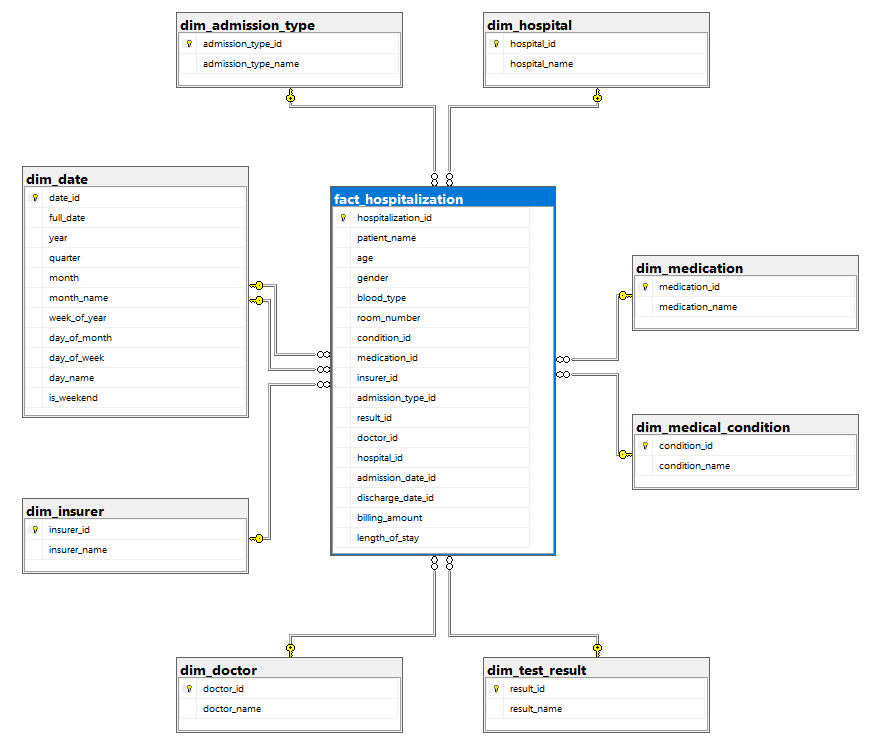